---
Phase 4-RL-2: Q-Learning → DQN — 從表格到深度學習
---

動態規劃需要知道環境的轉移機率 P(s'|s,a)
但大多數時候我們不知道 → 需要靠「經驗」學習

Q-Learning: 用表格記錄每個 (s, a) 的價值
DQN: 用神經網路取代表格（處理大狀態空間）

本檔涵蓋：
  1. Q-Learning (表格版)
  2. Epsilon-Greedy 探索策略
  3. DQN (Deep Q-Network)
  4. DQN 的關鍵技巧

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque
import random

# ============================================================================
# 1. Q-Learning — 表格版
# ============================================================================

1. Q-Learning — 不需要知道環境

Q-Learning 的核心更新公式：

  Q(s, a) ← Q(s, a) + α × [r + γ max_a' Q(s', a') - Q(s, a)]
                              └────── TD Target ──────┘
                        └────────── TD Error ──────────┘

  α = 學習率
  γ = 折扣因子
  TD Error = 目標值 - 當前估計

  直覺：
    1. 在狀態 s 做動作 a
    2. 觀察到 reward r 和下一個狀態 s'
    3. 估計未來最佳價值：max Q(s', a')
    4. 把 Q(s, a) 往「更好的估計」方向更新

  Q-Learning 是 off-policy:
    學的是最優策略（max），但行動可以用其他策略（如 ε-greedy）

Q-Table shape: (25, 4) (states × actions)

最後 100 episodes 平均獎勵: 9.29

學到的策略:
  →    →    →    ↓    ↓  
  ↑    X    →    →    ↓  
  ↓    →    ↓    X    ↓  
  ↓    X    ↓    →    ↓  
  →    →    →    →    G  


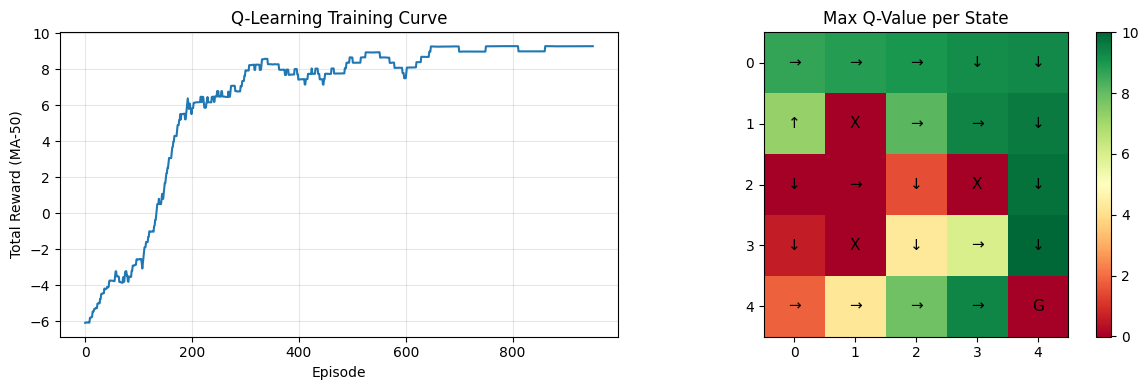


→ 圖表儲存至 rl/plots/02_q_learning.png


In [2]:
print("=" * 60)
print("1. Q-Learning — 不需要知道環境")
print("=" * 60)

print("""
Q-Learning 的核心更新公式：

  Q(s, a) ← Q(s, a) + α × [r + γ max_a' Q(s', a') - Q(s, a)]
                              └────── TD Target ──────┘
                        └────────── TD Error ──────────┘

  α = 學習率
  γ = 折扣因子
  TD Error = 目標值 - 當前估計

  直覺：
    1. 在狀態 s 做動作 a
    2. 觀察到 reward r 和下一個狀態 s'
    3. 估計未來最佳價值：max Q(s', a')
    4. 把 Q(s, a) 往「更好的估計」方向更新

  Q-Learning 是 off-policy:
    學的是最優策略（max），但行動可以用其他策略（如 ε-greedy）
""")


class GridWorld:
    """簡單的 Grid World"""
    def __init__(self, size=5):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        self.goal = (size - 1, size - 1)
        self.traps = [(1, 1), (2, 3), (3, 1)]
        self.reset()

    def reset(self):
        self.state = (0, 0)
        return self.state_to_idx(self.state)

    def state_to_idx(self, s):
        return s[0] * self.size + s[1]

    def step(self, action):
        dr, dc = self.actions[action]
        nr = max(0, min(self.size - 1, self.state[0] + dr))
        nc = max(0, min(self.size - 1, self.state[1] + dc))
        self.state = (nr, nc)

        if self.state == self.goal:
            return self.state_to_idx(self.state), 10.0, True
        elif self.state in self.traps:
            return self.state_to_idx(self.state), -5.0, True
        else:
            return self.state_to_idx(self.state), -0.1, False


def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=1.0,
               epsilon_min=0.01, epsilon_decay=0.995):
    """Q-Learning 演算法"""
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_history = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        for step in range(100):  # 最多 100 步
            # Epsilon-greedy 選動作
            if np.random.random() < epsilon:
                action = np.random.randint(env.n_actions)  # 探索
            else:
                action = Q[state].argmax()                  # 利用

            next_state, reward, done = env.step(action)
            total_reward += reward

            # Q-Learning 更新
            td_target = reward + gamma * Q[next_state].max() * (1 - done)
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            if done:
                break

        rewards_history.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_history


# 訓練
env = GridWorld(size=5)
Q, rewards = q_learning(env, episodes=1000)

print(f"Q-Table shape: {Q.shape} (states × actions)")
print(f"\n最後 100 episodes 平均獎勵: {np.mean(rewards[-100:]):.2f}")

# 顯示學到的策略
arrows = ['↑', '↓', '←', '→']
print("\n學到的策略:")
for r in range(env.size):
    for c in range(env.size):
        s = r * env.size + c
        if (r, c) == env.goal:
            print("  G  ", end="")
        elif (r, c) in env.traps:
            print("  X  ", end="")
        else:
            a = Q[s].argmax()
            print(f"  {arrows[a]}  ", end="")
    print()

# 畫學習曲線
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
axes[0].plot(smoothed)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward (MA-50)')
axes[0].set_title('Q-Learning Training Curve')
axes[0].grid(True, alpha=0.3)

# Q 值熱力圖
q_max = Q.max(axis=1).reshape(env.size, env.size)
im = axes[1].imshow(q_max, cmap='RdYlGn')
axes[1].set_title('Max Q-Value per State')
plt.colorbar(im, ax=axes[1])
for i in range(env.size):
    for j in range(env.size):
        s = i * env.size + j
        if (i, j) == env.goal:
            text = 'G'
        elif (i, j) in env.traps:
            text = 'X'
        else:
            text = arrows[Q[s].argmax()]
        axes[1].text(j, i, text, ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('phase-4-domains/rl/plots/02_q_learning.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 rl/plots/02_q_learning.png")

## 2. Epsilon-Greedy 探索


2. Exploration vs Exploitation

  探索 (Exploration): 嘗試新的動作，發現更好的策略
  利用 (Exploitation): 用已知最好的動作，拿到最大獎勵

  Epsilon-Greedy:
    以 ε 的機率隨機選動作（探索）
    以 1-ε 的機率選 Q 值最大的動作（利用）

    ε 通常從 1.0 逐漸衰減到 0.01
    開始: 多探索（不知道哪個好）
    後期: 多利用（已經知道哪個好）

  其他策略:
    Boltzmann (Softmax): P(a) ∝ exp(Q(s,a)/τ)
    UCB: 選 Q(s,a) + c × sqrt(ln(N)/N(s,a))



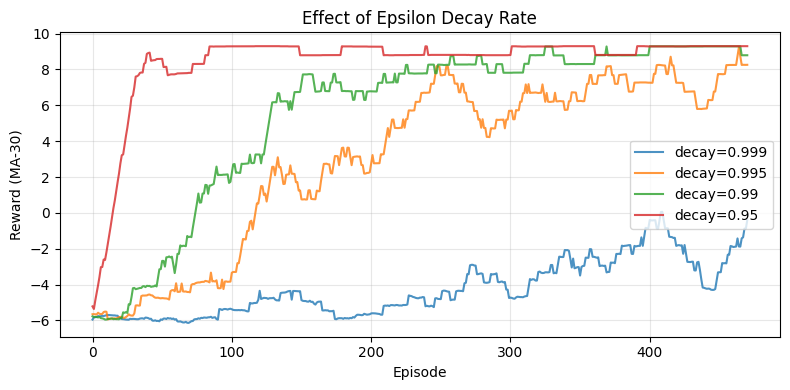

→ 圖表儲存至 rl/plots/02_epsilon_comparison.png


In [3]:
print("\n" + "=" * 60)
print("2. Exploration vs Exploitation")
print("=" * 60)

print("""
  探索 (Exploration): 嘗試新的動作，發現更好的策略
  利用 (Exploitation): 用已知最好的動作，拿到最大獎勵

  Epsilon-Greedy:
    以 ε 的機率隨機選動作（探索）
    以 1-ε 的機率選 Q 值最大的動作（利用）

    ε 通常從 1.0 逐漸衰減到 0.01
    開始: 多探索（不知道哪個好）
    後期: 多利用（已經知道哪個好）

  其他策略:
    Boltzmann (Softmax): P(a) ∝ exp(Q(s,a)/τ)
    UCB: 選 Q(s,a) + c × sqrt(ln(N)/N(s,a))
""")

# 比較不同 epsilon 策略
fig, ax = plt.subplots(figsize=(8, 4))

for eps_decay in [0.999, 0.995, 0.99, 0.95]:
    env_test = GridWorld(size=5)
    _, rewards_test = q_learning(env_test, episodes=500, epsilon_decay=eps_decay)
    window = 30
    smoothed = np.convolve(rewards_test, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=f'decay={eps_decay}', alpha=0.8)

ax.set_xlabel('Episode')
ax.set_ylabel('Reward (MA-30)')
ax.set_title('Effect of Epsilon Decay Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-4-domains/rl/plots/02_epsilon_comparison.png', dpi=100)
plt.show()
print("→ 圖表儲存至 rl/plots/02_epsilon_comparison.png")

## 3. DQN — 深度 Q 網路

In [4]:
print("\n" + "=" * 60)
print("3. DQN — 用神經網路取代 Q 表格")
print("=" * 60)

print("""
Q 表格的問題：
  Atari 遊戲的狀態 = 210×160×3 的像素 → 無法用表格
  圍棋的狀態空間 ≈ 10^170 → 根本存不下

DQN 的想法：
  用神經網路 Q_θ(s, a) 來近似 Q(s, a)
  輸入: state
  輸出: 每個 action 的 Q 值

  訓練目標:
  minimize (Q_θ(s, a) - [r + γ max_a' Q_θ(s', a')])²
                         └──── TD Target ────┘

DQN 的兩個關鍵技巧：
  1. Experience Replay: 把經驗存起來，隨機取出來訓練
     → 打破資料的時間相關性
  2. Target Network: 用一個延遲更新的網路計算 TD Target
     → 穩定訓練
""")


class ReplayBuffer:
    """經驗回放緩衝區"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    """Deep Q-Network"""
    def __init__(self, state_dim, n_actions, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class DQNAgent:
    """DQN 訓練器"""
    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.q_net = DQN(state_dim, n_actions).to(self.device)
        self.target_net = DQN(state_dim, n_actions).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(capacity=5000)

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.q_net(state_t)
            return q_values.argmax().item()

    def train_step(self, batch_size=32):
        if len(self.buffer) < batch_size:
            return 0

        states, actions, rewards, next_states, dones = self.buffer.sample(batch_size)

        states_t = torch.FloatTensor(states).to(self.device)
        actions_t = torch.LongTensor(actions).to(self.device)
        rewards_t = torch.FloatTensor(rewards).to(self.device)
        next_states_t = torch.FloatTensor(next_states).to(self.device)
        dones_t = torch.FloatTensor(dones).to(self.device)

        # 當前 Q 值
        q_values = self.q_net(states_t)
        q_value = q_values.gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # Target Q 值（用 target network）
        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(1)[0]
            td_target = rewards_t + self.gamma * next_q * (1 - dones_t)

        loss = F.mse_loss(q_value, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# 用 DQN 訓練 GridWorld
def state_to_onehot(s_idx, n_states):
    """把狀態索引轉成 one-hot"""
    v = np.zeros(n_states)
    v[s_idx] = 1.0
    return v


env = GridWorld(size=5)
agent = DQNAgent(state_dim=env.n_states, n_actions=env.n_actions, lr=1e-3)

print("DQN 訓練中...")
dqn_rewards = []

for ep in range(300):
    s_idx = env.reset()
    state = state_to_onehot(s_idx, env.n_states)
    total_reward = 0

    for step in range(100):
        action = agent.select_action(state)
        next_s_idx, reward, done = env.step(action)
        next_state = state_to_onehot(next_s_idx, env.n_states)

        agent.buffer.push(state, action, reward, next_state, done)
        agent.train_step(batch_size=32)

        state = next_state
        total_reward += reward
        if done:
            break

    dqn_rewards.append(total_reward)
    agent.decay_epsilon()

    if ep % 10 == 0:
        agent.update_target()

    if ep % 100 == 0:
        avg = np.mean(dqn_rewards[-50:]) if len(dqn_rewards) >= 50 else np.mean(dqn_rewards)
        print(f"  Episode {ep:3d}: avg_reward={avg:.2f}, ε={agent.epsilon:.3f}")

print(f"最後 50 episodes 平均: {np.mean(dqn_rewards[-50:]):.2f}")


3. DQN — 用神經網路取代 Q 表格

Q 表格的問題：
  Atari 遊戲的狀態 = 210×160×3 的像素 → 無法用表格
  圍棋的狀態空間 ≈ 10^170 → 根本存不下

DQN 的想法：
  用神經網路 Q_θ(s, a) 來近似 Q(s, a)
  輸入: state
  輸出: 每個 action 的 Q 值

  訓練目標:
  minimize (Q_θ(s, a) - [r + γ max_a' Q_θ(s', a')])²
                         └──── TD Target ────┘

DQN 的兩個關鍵技巧：
  1. Experience Replay: 把經驗存起來，隨機取出來訓練
     → 打破資料的時間相關性
  2. Target Network: 用一個延遲更新的網路計算 TD Target
     → 穩定訓練



DQN 訓練中...
  Episode   0: avg_reward=-5.20, ε=0.995


  Episode 100: avg_reward=-4.43, ε=0.603


  Episode 200: avg_reward=-1.34, ε=0.365


最後 50 episodes 平均: -1.06


## 4. DQN 的進階技巧

In [5]:
print("\n" + "=" * 60)
print("4. DQN 的進階技巧")
print("=" * 60)

print("""
原始 DQN (2013, DeepMind) → 玩 Atari 遊戲超越人類

後續改進：
  1. Double DQN (2015):
     問題: max 運算導致 Q 值過高估計
     解法: 用 q_net 選動作，用 target_net 評估
     a* = argmax Q_θ(s', a)
     target = r + γ Q_θ'(s', a*)

  2. Dueling DQN (2016):
     把 Q(s,a) 拆成：
     Q(s,a) = V(s) + A(s,a)
     V(s): 這個狀態本身好不好
     A(s,a): 這個動作比平均好多少（Advantage）

  3. Prioritized Experience Replay (2016):
     問題: 均勻抽樣不太高效
     解法: TD error 大的經驗被抽到的機率更高
     → 學習效率大幅提升

  4. Rainbow DQN (2018):
     把以上所有技巧結合在一起

  5. Distributional RL (C51, QR-DQN):
     學的不是 Q 值的期望，而是整個分佈
""")


4. DQN 的進階技巧

原始 DQN (2013, DeepMind) → 玩 Atari 遊戲超越人類

後續改進：
  1. Double DQN (2015):
     問題: max 運算導致 Q 值過高估計
     解法: 用 q_net 選動作，用 target_net 評估
     a* = argmax Q_θ(s', a)
     target = r + γ Q_θ'(s', a*)

  2. Dueling DQN (2016):
     把 Q(s,a) 拆成：
     Q(s,a) = V(s) + A(s,a)
     V(s): 這個狀態本身好不好
     A(s,a): 這個動作比平均好多少（Advantage）

  3. Prioritized Experience Replay (2016):
     問題: 均勻抽樣不太高效
     解法: TD error 大的經驗被抽到的機率更高
     → 學習效率大幅提升

  4. Rainbow DQN (2018):
     把以上所有技巧結合在一起

  5. Distributional RL (C51, QR-DQN):
     學的不是 Q 值的期望，而是整個分佈



## 小結

In [6]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
  方法          需要環境模型    適合的問題
  ──────────────────────────────────────────────
  動態規劃      需要           小型已知環境
  Q-Learning    不需要         小型離散狀態
  DQN           不需要         大型/連續狀態

  DQN 的核心：
  1. 用神經網路 Q_θ(s,a) 近似 Q 表格
  2. Experience Replay 打破相關性
  3. Target Network 穩定訓練
  4. ε-Greedy 平衡探索與利用

  Q-Learning 的限制：
  - 只能處理離散動作（上下左右、按鍵）
  - 連續動作（油門=0.73）→ 需要 Policy Gradient

下一步：03_policy_gradient.py — Policy Gradient 和 PPO
""")


小結

  方法          需要環境模型    適合的問題
  ──────────────────────────────────────────────
  動態規劃      需要           小型已知環境
  Q-Learning    不需要         小型離散狀態
  DQN           不需要         大型/連續狀態

  DQN 的核心：
  1. 用神經網路 Q_θ(s,a) 近似 Q 表格
  2. Experience Replay 打破相關性
  3. Target Network 穩定訓練
  4. ε-Greedy 平衡探索與利用

  Q-Learning 的限制：
  - 只能處理離散動作（上下左右、按鍵）
  - 連續動作（油門=0.73）→ 需要 Policy Gradient

下一步：03_policy_gradient.py — Policy Gradient 和 PPO

